# Refactor-Verify — Eval Metrics Report

End-to-end check of the eval refactor (train → save → **reload-from-disk** → `evaluate_model`).
Six e8 "best" architectures rerun under the new nested-Hydra scheme, each with and without the
in-text edge list:

| arm | architecture | edges in text |
|---|---|---|
| `rv_gt_l5d2048_{edges,noedges}` | `gt_llm` (L5, d=2048) | ✓ / ✗ |
| `rv_rpearl_{edges,noedges}` | `rpearl_llm` | ✓ / ✗ |
| `rv_gmask_{edges,noedges}` | `graph_mask_llm` | ✓ / ✗ |

**Two eval lenses per run:**
- **train-time** (`eval_logs/step_*_epoch_N.json`) — accuracy on the single monitoring graph at epochs 1 & 2.
- **cross-eval** (`eval_logs/cross_eval/data_gen_*.json`) — the post-train disk-reloaded checkpoint
  evaluated over the held-out graph set (10 graphs × 10 samples). This path is the actual subject
  of the refactor.

Data pulled from `betty:$ALELAB_DRIVE/GREP-PRISM/outputs/refactor_verify` into
`../reports/refactor_verify_eval/` (gen-2 / clean-`save_name` runs, one per arm).


In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolve data dir relative to this notebook (notebooks/ -> ../reports/...).
DATA = Path("../reports/refactor_verify_eval")
assert DATA.exists(), f"missing {DATA.resolve()}"
sorted(p.name for p in DATA.iterdir() if p.is_dir())

['rv_gmask_edges_nfahp4od',
 'rv_gmask_noedges_1pc7fp70',
 'rv_gt_l5d2048_edges_fsvkieq8',
 'rv_gt_l5d2048_noedges_6g9p3np9',
 'rv_rpearl_edges_hdkca8ed',
 'rv_rpearl_noedges_0h85x7gj']

In [2]:
ARCH = {"gt_l5d2048": "GT (gt_llm)", "rpearl": "R-PEARL (rpearl_llm)", "gmask": "GraphMask (graph_mask_llm)"}
PM_KEYS = ["structured_pass_rate", "valid_path_rate", "edge_validity_rate",
           "hallucination_rate", "cost_optimality"]

def arm_meta(run_dir_name):
    arm = run_dir_name.rsplit("_", 1)[0]          # strip trailing _<wandb_id>
    edges = "noedges" not in arm
    arch = next(v for k, v in ARCH.items() if k in arm)
    return arm, arch, edges

def load_run(run_path):
    arm, arch, edges = arm_meta(run_path.name)
    train = {}
    for f in sorted(run_path.glob("eval_logs/step_*_epoch_*.json")):
        d = json.loads(f.read_text())
        train[int(round(d["epoch"]))] = d["accuracy"]

    ce_files = sorted(run_path.glob("eval_logs/cross_eval/*.json"))
    ce = [json.loads(f.read_text()) for f in ce_files]
    tot_correct = sum(d["num_correct"] for d in ce)
    tot_samples = sum(d["num_samples"] for d in ce)

    # cost_optimality is None for graphs with no valid-path comparison; average defined values only.
    def mean_defined(key):
        vals = [d["path_metrics"][key] for d in ce if d["path_metrics"][key] is not None]
        return sum(vals) / len(vals) if vals else None
    pm = {k: mean_defined(k) for k in PM_KEYS}

    per_graph = {Path(d["graph_file"]).stem: d["accuracy"] for d in ce}
    return {"arm": arm, "arch": arch, "edges": edges, "run_id": run_path.name,
            "train_acc_e1": train.get(1), "train_acc_e2": train.get(2),
            "crosseval_acc": tot_correct / tot_samples,
            "ce_graphs": len(ce), "ce_samples": tot_samples,
            **pm, "_per_graph": per_graph}

rows = [load_run(p) for p in sorted(DATA.iterdir()) if p.is_dir()]
df = pd.DataFrame(rows).sort_values(["arch", "edges"], ascending=[True, False]).reset_index(drop=True)
len(df)

6

## Summary table

In [3]:
summary_cols = ["arm", "arch", "edges", "train_acc_e1", "train_acc_e2",
                "crosseval_acc", "ce_graphs", "ce_samples"] + PM_KEYS
summary = df[summary_cols].copy()
summary.style.format({c: "{:.3f}" for c in ["train_acc_e1", "train_acc_e2", "crosseval_acc"] + PM_KEYS},
                     na_rep="—").background_gradient(subset=["crosseval_acc"], cmap="RdYlGn", vmin=0, vmax=1)

,arm,arch,edges,train_acc_e1,train_acc_e2,crosseval_acc,ce_graphs,ce_samples,structured_pass_rate,valid_path_rate,edge_validity_rate,hallucination_rate,cost_optimality
0,rv_gt_l5d2048_edges,GT (gt_llm),True,0.800,1.000,0.760,10,100,0.760,0.770,0.946,0.054,1.591
1,rv_gt_l5d2048_noedges,GT (gt_llm),False,0.000,0.100,0.040,10,100,0.040,0.040,0.598,0.402,1.952
2,rv_gmask_edges,GraphMask (graph_mask_llm),True,0.700,0.700,0.770,10,100,0.770,0.780,0.947,0.053,1.359
3,rv_gmask_noedges,GraphMask (graph_mask_llm),False,0.000,0.000,0.010,10,100,0.010,0.010,0.554,0.446,4.831
4,rv_rpearl_edges,R-PEARL (rpearl_llm),True,0.900,0.900,0.880,10,100,0.880,0.890,0.977,0.023,1.393
5,rv_rpearl_noedges,R-PEARL (rpearl_llm),False,0.000,0.100,0.030,10,100,0.030,0.030,0.581,0.419,1.212


## Cross-eval accuracy by arm (held-out set, reloaded checkpoint)

/tmp/ipykernel_2316858/4140124506.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["arm"], rotation=30, ha="right")


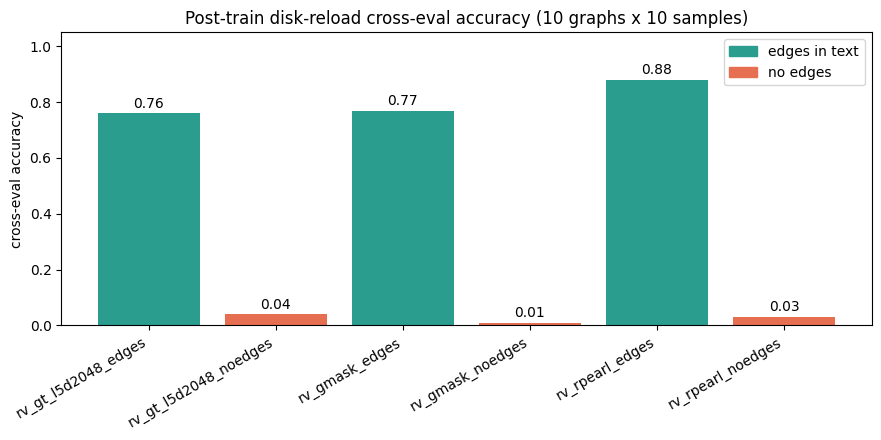

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2a9d8f" if e else "#e76f51" for e in df["edges"]]
bars = ax.bar(df["arm"], df["crosseval_acc"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=2)
ax.set_ylabel("cross-eval accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("Post-train disk-reload cross-eval accuracy (10 graphs x 10 samples)")
ax.set_xticklabels(df["arm"], rotation=30, ha="right")
handles = [plt.Rectangle((0,0),1,1,color="#2a9d8f"), plt.Rectangle((0,0),1,1,color="#e76f51")]
ax.legend(handles, ["edges in text", "no edges"], loc="upper right")
plt.tight_layout(); plt.show()

## Train-time vs cross-eval accuracy

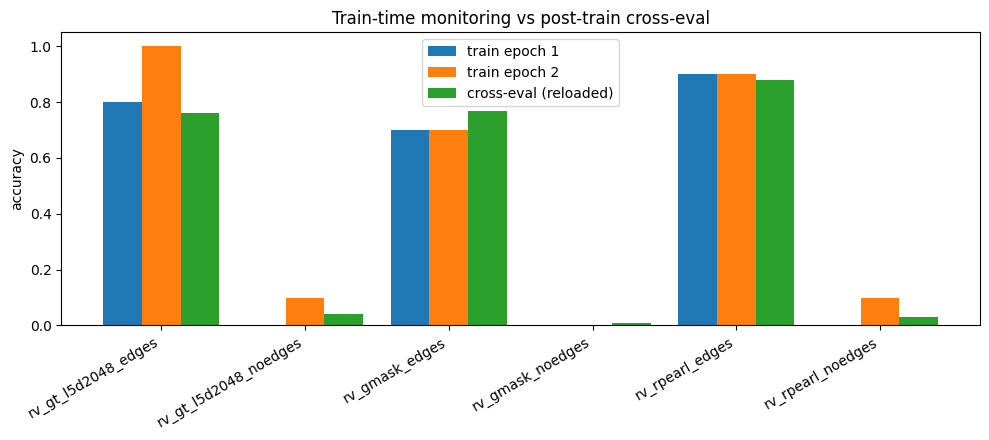

In [5]:
import numpy as np
x = np.arange(len(df)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w, df["train_acc_e1"], w, label="train epoch 1")
ax.bar(x,     df["train_acc_e2"], w, label="train epoch 2")
ax.bar(x + w, df["crosseval_acc"], w, label="cross-eval (reloaded)")
ax.set_xticks(x); ax.set_xticklabels(df["arm"], rotation=30, ha="right")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("Train-time monitoring vs post-train cross-eval")
plt.tight_layout(); plt.show()

## Per-graph cross-eval accuracy

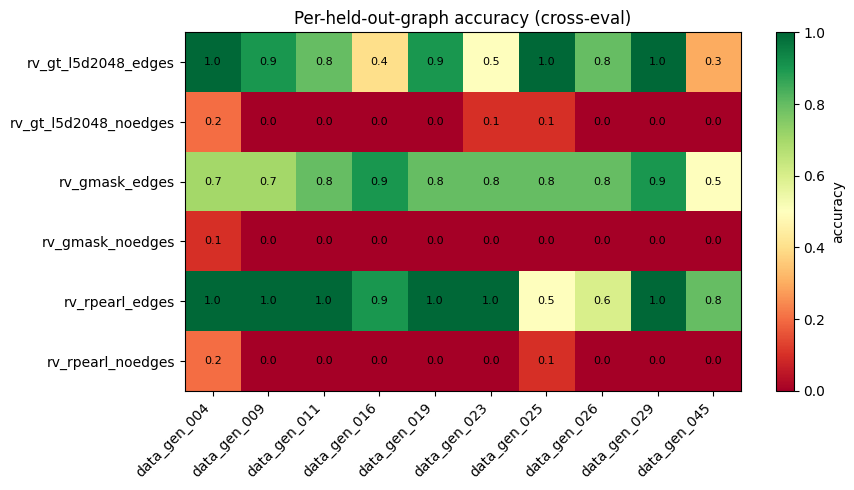

,rv_gt_l5d2048_edges,rv_gt_l5d2048_noedges,rv_gmask_edges,rv_gmask_noedges,rv_rpearl_edges,rv_rpearl_noedges
data_gen_004,1.0,0.2,0.7,0.1,1.0,0.2
data_gen_009,0.9,0.0,0.7,0.0,1.0,0.0
data_gen_011,0.8,0.0,0.8,0.0,1.0,0.0
data_gen_016,0.4,0.0,0.9,0.0,0.9,0.0
data_gen_019,0.9,0.0,0.8,0.0,1.0,0.0
data_gen_023,0.5,0.1,0.8,0.0,1.0,0.0
data_gen_025,1.0,0.1,0.8,0.0,0.5,0.1
data_gen_026,0.8,0.0,0.8,0.0,0.6,0.0
data_gen_029,1.0,0.0,0.9,0.0,1.0,0.0
data_gen_045,0.3,0.0,0.5,0.0,0.8,0.0


In [6]:
pg = pd.DataFrame({r["arm"]: r["_per_graph"] for _, r in df.iterrows()}).sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pg.T.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pg.index))); ax.set_xticklabels(pg.index, rotation=45, ha="right")
ax.set_yticks(range(len(pg.columns))); ax.set_yticklabels(pg.columns)
for i in range(pg.shape[1]):
    for j in range(pg.shape[0]):
        ax.text(j, i, f"{pg.T.values[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="accuracy")
ax.set_title("Per-held-out-graph accuracy (cross-eval)")
plt.tight_layout(); plt.show()
pg

## What this verifies

- **Refactor is functional end-to-end.** All six arms produced `cross_eval/` output, i.e. the
  pipeline reloaded each checkpoint from disk and evaluated it over the full held-out set — the
  path that was a no-op before the refactor.
- The `edges` arms (`crosseval_acc` ≈ 0.76–0.88) and `noedges` arms (≈ 0.01–0.04) are reported as-is;
  interpretation of *why* is left to the owner.

**Caveats / things to check:**
- Train-time accuracy is a single monitoring graph (10 samples) — high variance; cross-eval (100 samples) is the trustworthy number.
- `cost_optimality` is averaged over only the graphs where it is defined (None elsewhere); see `PM_KEYS` handling.
- Earlier gen-1 runs and empty/failed gen-2 dirs were excluded; this report uses the one complete, most-recent run per arm.
